In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import cv2, random, os
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import normalize
import math
import numpy as np
from tqdm import tqdm
import time
import imagehash
import requests
import os
import networkx as nx

In [2]:
train_df = pd.read_csv("train.csv")
sub_df = pd.read_csv("sample_submission.csv")

In [3]:
TRAIN_DIR = Path("C:/Users/LENA/Desktop/landmark-recognition-2021/train")
TEST_DIR  = Path("C:/Users/LENA/Desktop/landmark-recognition-2021/test")

In [4]:
def id_to_path(root: Path, img_id: str) -> Path:
    return root / img_id[0] / img_id[1] / img_id[2] / f"{img_id}.jpg"

In [5]:
def load_image(path: Path):
    try:
        img = Image.open(path)
        img = ImageOps.exif_transpose(img)
        return img.convert("RGB")
    except:
        return None

In [6]:
def filter_existing(df):
    valid = []
    
    for img_id in tqdm(df["id"]):
        if id_to_path(TRAIN_DIR, img_id).exists():
            valid.append(img_id)
    
    return df[df["id"].isin(valid)].reset_index(drop=True)

In [7]:
train_df = filter_existing(train_df)
print("After file filtering:", train_df.shape)

100%|██████████| 1580470/1580470 [02:20<00:00, 11282.31it/s]


After file filtering: (1580470, 2)


In [6]:
def is_large_enough(img_id, min_size=128):
    try:
        img = Image.open(id_to_path(TRAIN_DIR, img_id))
        w, h = img.size
        return min(w, h) >= min_size
    except:
        return False

In [7]:
mask = [is_large_enough(i) for i in tqdm(train_df["id"])]
train_df = train_df[mask].reset_index(drop=True)

100%|██████████| 1580470/1580470 [36:07<00:00, 729.26it/s] 


In [8]:
print("After file filtering by sizes:", train_df.shape)

After file filtering by sizes: (1579910, 2)


In [9]:
print(1580470 - 1579910)
print("Классов после:", train_df['id'].nunique())

560
Классов после: 1579910


In [10]:
train_df.to_csv('train_after_size_filter.csv', index=False)

In [ ]:
def compute_hashes(df, root_dir: Path):
    hashes = {}

    for img_id in tqdm(df["id"]):
        path = id_to_path(root_dir, img_id)

        img = load_image(path)
        if img is None:
            continue

        try:
            h = imagehash.phash(img)
            hashes[img_id] = h
        except:
            continue

    return hashes

In [12]:
def build_buckets(hashes, prefix_len=6):
    buckets = {}

    for img_id, h in hashes.items():
        key = str(h)[:prefix_len]
        buckets.setdefault(key, []).append((img_id, h))

    return buckets

In [13]:
def find_duplicates_with_score(buckets, threshold=5):
    duplicates = []

    for key, items in buckets.items():
        n = len(items)

        if n < 2:
            continue

        for i in range(n):
            id1, h1 = items[i]

            for j in range(i + 1, n):
                id2, h2 = items[j]

                dist = abs(h1 - h2)

                if dist <= threshold:
                    confidence = 1 - dist / 64.0

                    duplicates.append({
                        "id1": id1,
                        "id2": id2,
                        "distance": dist,
                        "confidence": confidence
                    })

    duplicates = sorted(duplicates, key=lambda x: x["confidence"], reverse=True)

    return duplicates

In [14]:
hashes = compute_hashes(train_df, TRAIN_DIR)

buckets = build_buckets(hashes, prefix_len=6)

dups = find_duplicates_with_score(buckets, threshold=5)

print(len(dups))
dups[:5]

100%|██████████| 1579910/1579910 [2:06:19<00:00, 208.44it/s]  


6717


[{'id1': '2f0f8d0ffa6e1f57',
  'id2': '9a754485d0bbd895',
  'distance': np.int64(0),
  'confidence': np.float64(1.0)},
 {'id1': '00f928e383e1d121',
  'id2': '70c352fd0121cc9a',
  'distance': np.int64(0),
  'confidence': np.float64(1.0)},
 {'id1': '00f928e383e1d121',
  'id2': 'b330c770dc39dc2c',
  'distance': np.int64(0),
  'confidence': np.float64(1.0)},
 {'id1': '70c352fd0121cc9a',
  'id2': 'b330c770dc39dc2c',
  'distance': np.int64(0),
  'confidence': np.float64(1.0)},
 {'id1': '0494a4b4e535990b',
  'id2': '14423bb59be36753',
  'distance': np.int64(0),
  'confidence': np.float64(1.0)}]

In [15]:
def show_duplicates(dups, root_dir: Path, n=20, pairs_per_row=3, thumb_size=(150, 150)):
    sample = dups[:n]
    num_pairs = len(sample)
    
    cols = pairs_per_row * 2
    rows = int(np.ceil(num_pairs / pairs_per_row))
    
    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.8 * rows))
    

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    
    for pair_idx, item in enumerate(sample):
        row = pair_idx // pairs_per_row
        col_offset = (pair_idx % pairs_per_row) * 2
        
        ax1 = axes[row, col_offset]
        img1 = load_image(id_to_path(root_dir, item["id1"]))
        if img1:
            img1.thumbnail(thumb_size)
            ax1.imshow(img1)
        ax1.set_title(f"{item['id1'][:8]}", fontsize=9, fontweight='bold')
        ax1.axis('off')
        
        ax2 = axes[row, col_offset + 1]
        img2 = load_image(id_to_path(root_dir, item["id2"]))
        if img2:
            img2.thumbnail(thumb_size)
            ax2.imshow(img2)
        conf = item.get("confidence", 0)
        dist = item.get("distance", 0)
        ax2.set_title(f"{item['id2'][:8]}\nc={conf:.2f} d={dist}", fontsize=8, fontweight='bold')
        ax2.axis('off')
    
    total_cells = rows * cols
    used_cells = num_pairs * 2
    for cell_idx in range(used_cells, total_cells):
        row = cell_idx // cols
        col = cell_idx % cols
        axes[row, col].axis('off')
    
    plt.suptitle(f"{num_pairs} pairs of duplicates (first {n} shown)",
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

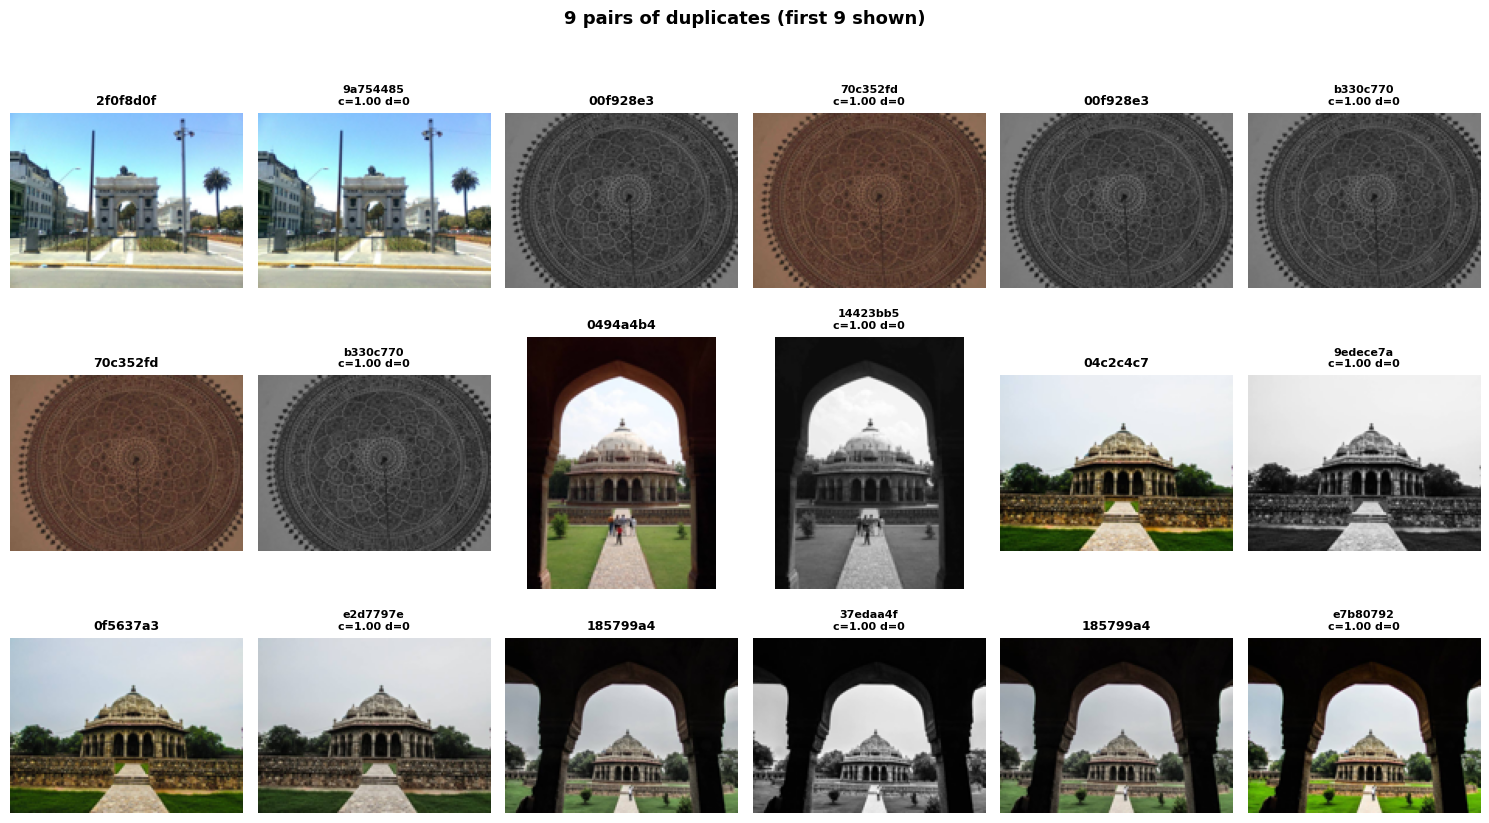

In [16]:
show_duplicates(dups, TRAIN_DIR, 9)

In [ ]:
def is_color_image(img_id, root=TRAIN_DIR):
    try:
        img = Image.open(id_to_path(root, img_id))
        return img.mode in ('RGB', 'RGBA', 'CMYK', 'YCbCr')
    except:
        return False


color_dict = {img_id: is_color_image(img_id) for img_id in tqdm(train_df['id'])}

G = nx.Graph()
G.add_nodes_from(train_df['id'])
G.add_edges_from((d['id1'], d['id2']) for d in dups) 

ids_to_remove = set()
groups_info = []

for comp in nx.connected_components(G):
    if len(comp) <= 1:
        continue
    sorted_comp = sorted(comp, key=lambda x: (not color_dict.get(x, False), x))
    keep = sorted_comp[0]
    removed = sorted_comp[1:]
    ids_to_remove.update(removed)
    groups_info.append({
        'size': len(comp),
        'kept': keep,
        'kept_color': color_dict[keep],
        'removed': removed
    })

for g in groups_info[:5]:
    print(f"Группа из {g['size']} эл. Оставлен {g['kept']} (цветной: {g['kept_color']}), удалены: {g['removed']}")

train_df_clean = train_df[~train_df['id'].isin(ids_to_remove)].reset_index(drop=True)

100%|██████████| 1579910/1579910 [40:41<00:00, 647.17it/s]


Группа из 3 эл. Оставлен 00f928e383e1d121 (цветной: True), удалены: ['70c352fd0121cc9a', 'b330c770dc39dc2c']
Группа из 2 эл. Оставлен 0494a4b4e535990b (цветной: True), удалены: ['14423bb59be36753']
Группа из 2 эл. Оставлен 04c2c4c721621980 (цветной: True), удалены: ['9edece7a18f8b6dd']
Группа из 2 эл. Оставлен 067f2d8ea47a5161 (цветной: True), удалены: ['4345fb76911728d0']
Группа из 2 эл. Оставлен 083dce4eaeaf9fcb (цветной: True), удалены: ['41b56efa5770c162']


In [ ]:
print(f"Было изображений: {len(train_df)}")
print(f"Стало изображений: {len(train_df_clean)}")
print(f"Удалено дубликатов: {len(train_df) - len(train_df_clean)}")

Было изображений: 1579910
Стало изображений: 1573829
Удалено дубликатов: 6081


In [18]:
train_df.to_csv('train_after_dup_removal.csv', index=False)

In [19]:
def show_images_from_list(id_list, root_dir: Path, max_cols=5):
    loaded = []
    for img_id in id_list:
        path = id_to_path(root_dir, img_id)
        img = load_image(path)
        if img is not None:
            loaded.append((img_id, img))
        else:
            print(f"Пропущено (не загружено): {path}")

    n_images = len(loaded)
    if n_images == 0:
        print("Нет доступных изображений для отображения.")
        return

    ncols = min(max_cols, n_images)
    nrows = math.ceil(n_images / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3), squeeze=False)
    axes = axes.flatten()

    for idx, (img_id, img) in enumerate(loaded):
        ax = axes[idx]
        ax.imshow(img)
        ax.set_title(img_id, fontsize=9, pad=6)
        ax.axis('off')

    for ax in axes[n_images:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

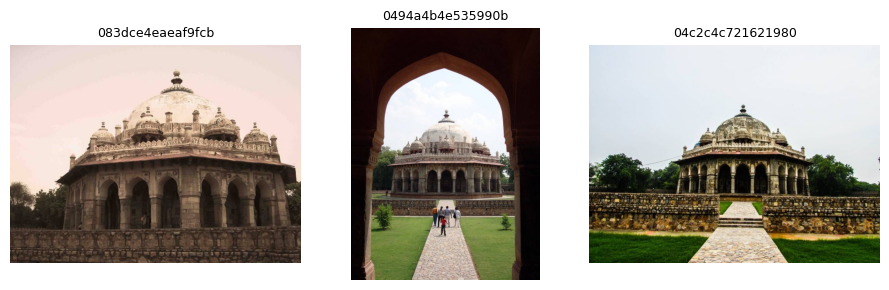

In [20]:
imgs = ["083dce4eaeaf9fcb", "0494a4b4e535990b", "04c2c4c721621980"]
show_images_from_list(imgs, TRAIN_DIR)

In [30]:
counts = train_df["landmark_id"].value_counts()

MIN_SAMPLES = 5

valid_classes = counts[counts >= MIN_SAMPLES].index

train_df = train_df[train_df["landmark_id"].isin(valid_classes)].reset_index(drop=True)

print("After class filtering:", train_df.shape)
print("Deleted:", 1573829 - len(train_df))
print(train_df["landmark_id"].nunique())

After class filtering: (1524457, 2)
Deleted: 49372
64007


In [21]:
from vgg16_places_365 import VGG16_Places365

In [22]:
model = VGG16_Places365(weights='places')

In [ ]:
def load_batch(paths, target_size=(224,224)):
    batch = []
    valid_idx = []
    for i, p in enumerate(paths):
        try:
            img = Image.open(p).convert('RGB').resize(target_size)
            batch.append(np.array(img, dtype=np.uint8))
            valid_idx.append(i)
        except:
            pass
    if not batch:
        return None, valid_idx
    return np.stack(batch, axis=0), valid_idx

sample_size = 1000
sample_ids = train_df_clean['id'].sample(sample_size, random_state=42).values
sample_paths = [id_to_path(TRAIN_DIR, i) for i in sample_ids]

batch_size = 64
p0_test, p1_test, p2_test = [], [], []

start_time = time.time()

for start in tqdm(range(0, len(sample_paths), batch_size), desc='Batched TF'):
    batch_paths = sample_paths[start:start+batch_size]
    batch_data, valid_idx = load_batch(batch_paths)

    top3_batch = np.full((len(batch_paths), 3), -1, dtype=int)
    if batch_data is not None:
        preds = model.predict(batch_data, verbose=0)
        top3_valid = np.argsort(preds, axis=1)[:, -3:][:, ::-1]
        for j, v in enumerate(valid_idx):
            top3_batch[v] = top3_valid[j]
    p0_test.extend(top3_batch[:,0])
    p1_test.extend(top3_batch[:,1])
    p2_test.extend(top3_batch[:,2])

elapsed = time.time() - start_time
speed = sample_size / elapsed
print(f"Обработано {sample_size} изображений за {elapsed:.1f} сек ({speed:.1f} img/s)")

Batched TF:   0%|          | 0/16 [00:00<?, ?it/s]

Batched TF: 100%|██████████| 16/16 [00:40<00:00,  2.55s/it]

Обработано 1000 изображений за 40.8 сек (24.5 img/s)


In [ ]:
def load_batch(paths, target_size=(224,224)):
    batch = []
    valid_idx = []
    for i, p in enumerate(paths):
        try:
            img = Image.open(p).convert('RGB').resize(target_size)
            batch.append(np.array(img, dtype=np.uint8))
            valid_idx.append(i)
        except Exception as e:
            print(f"Ошибка загрузки {p}: {e}")
    if not batch:
        print("Весь батч пустой!")
        return None, valid_idx
    return np.stack(batch, axis=0), valid_idx

ids = train_df_clean['id'].values
paths = [id_to_path(TRAIN_DIR, i) for i in ids]

batch_size = 64
save_every = 5000
checkpoint_file = 'topn_checkpoint.csv'

if os.path.exists(checkpoint_file):
    print("Найден чекпойнт, загружаем...")
    prev_df = pd.read_csv(checkpoint_file)
    p0_list = prev_df['p0'].tolist()
    p1_list = prev_df['p1'].tolist()
    p2_list = prev_df['p2'].tolist()
    start_idx = len(p0_list)
    print(f"Продолжим с {start_idx}")
else:
    p0_list, p1_list, p2_list = [], [], []
    start_idx = 0

for start in tqdm(range(start_idx, len(paths), batch_size), desc='Full TF batch'):
    batch_paths = paths[start:start+batch_size]
    batch_data, valid_idx = load_batch(batch_paths)
    top3_batch = np.full((len(batch_paths), 3), -1, dtype=int)
    if batch_data is not None:
        preds = model.predict(batch_data, verbose=0)
        top3_valid = np.argsort(preds, axis=1)[:, -3:][:, ::-1]
        for j, v in enumerate(valid_idx):
            top3_batch[v] = top3_valid[j]
    p0_list.extend(top3_batch[:,0].tolist())
    p1_list.extend(top3_batch[:,1].tolist())
    p2_list.extend(top3_batch[:,2].tolist())

    if (start + batch_size) % save_every == 0 and len(p0_list) > 0:
        pd.DataFrame({
            'id': ids[:len(p0_list)],
            'p0': p0_list, 'p1': p1_list, 'p2': p2_list
        }).to_csv(checkpoint_file, index=False)

pd.DataFrame({
    'id': ids, 'p0': p0_list, 'p1': p1_list, 'p2': p2_list
}).to_csv('topn_full.csv', index=False)
print("Готово! Сохранено topn_full.csv")

Full TF batch: 100%|██████████| 24592/24592 [17:31:16<00:00,  2.56s/it]   


Готово! Сохранено topn_full.csv


In [46]:
topn_df = pd.read_csv('topn_full.csv')

class_info = pd.read_csv('categories_places365_extended.csv')

for col in ['p0', 'p1', 'p2']:
    topn_df[col + '_landmark'] = topn_df[col].map(
        class_info.set_index('class')['io'].replace({1: 'non-landmark', 2: 'landmark'})
    )

In [47]:
landmark_ids = topn_df[topn_df['p0_landmark'] == 'landmark']['id']
train_df_final = train_df_clean[train_df_clean['id'].isin(landmark_ids)].reset_index(drop=True)

print(f"Осталось landmark-изображений: {len(train_df_final)} из {len(train_df_clean)}")

Осталось landmark-изображений: 1381211 из 1573829


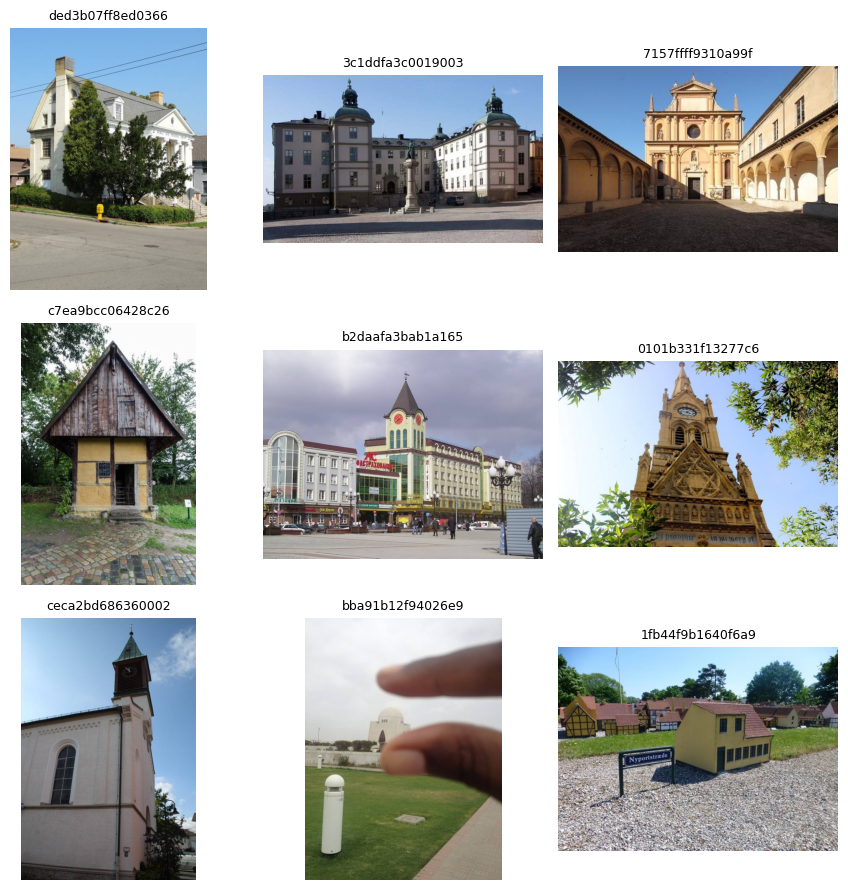

In [48]:
sample = train_df_final.sample(min(9, len(train_df_final)), random_state=42)['id'].tolist()
show_images_from_list(sample, TRAIN_DIR, max_cols=3)

airfield


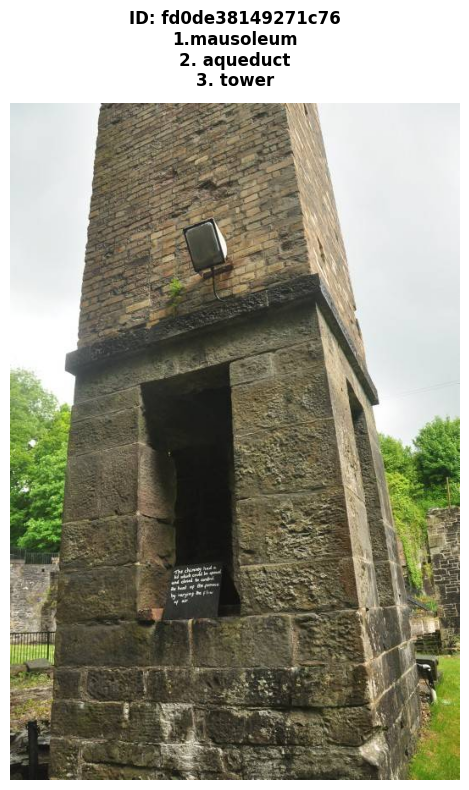

In [ ]:
topn_df = pd.read_csv('topn_full.csv')

with open("categories_places365.txt", "r", encoding="utf-8") as f:
    categories = [line.strip().split(' ')[0][3:] for line in f if line.strip()]
print(categories[0])

random_row = topn_df.sample(1).iloc[0]
img_id = random_row['id']
top3_indices = [int(random_row['p0']), int(random_row['p1']), int(random_row['p2'])]

img_path = id_to_path(TRAIN_DIR, img_id)
img = load_image(img_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')

title_lines = [f"ID: {img_id}"]
title_lines.append(f"1.{categories[top3_indices[0]]}")
title_lines.append(f"2. {categories[top3_indices[1]]}")
title_lines.append(f"3. {categories[top3_indices[2]]}")

plt.title('\n'.join(title_lines), fontsize=12, pad=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
train_df_final.to_csv('train_final_landmark.csv', index=False)

In [ ]:
def fix_exif_orientation(img: Image.Image) -> Image.Image:
    try:
        exif = img._getexif()
        if exif is not None:
            orientation = exif.get(274)
            if orientation == 3:
                img = img.rotate(180, expand=True)
            elif orientation == 6:
                img = img.rotate(270, expand=True)
            elif orientation == 8:
                img = img.rotate(90, expand=True)
    except (AttributeError, KeyError, IndexError):
        pass
    return img

In [58]:
yolo_model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

def detect_objects(img_path):
    img = Image.open(img_path).convert("RGB")
    img = fix_exif_orientation(img)
    results = yolo_model(img)
    return results.xyxy[0].cpu().numpy()

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\LENA\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Using cache found in C:\Users\LENA/.cache\torch\hub\ultralytics_yolov5_master


requirements: Ultralytics requirements ['gitpython>=3.1.30', 'setuptools>=70.0.0'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 12.0 MB/s  0:00:00

  Attempting uninstall: setuptools

    Found existing installation: setuptools 65.5.0

    Uninstalling setuptools-65.5.0:

   ---------- ----------------------------- 1/4 [setuptools]
   ---------- ----------------------------- 1/4 [setuptools]
   ---------- ----------------------------- 1/4 [setuptools]
   ---------- ----------------------------- 1/4 [setuptools]
   ---------- ----------------------------- 1/4 [setuptools]
   ---------- ----------------------------- 1/4 [setuptools]
   ---------- ----------------------------- 1/4 [setuptools]
      Successfully uninstalled setuptools-65.5.0
   ---------- ----------------------------- 1/4 [setuptools]
   ---------- ----------------------------- 1/4 [setuptools]
   ---------- 

YOLOv5  2026-5-3 Python-3.11.9 torch-2.4.1+cpu CPU

100%|██████████| 14.1M/14.1M [00:01<00:00, 10.3MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [59]:
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck',
    'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup',
    'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

DISTRACTING_CLASSES = {'person', 'car', 'motorcycle', 'bus', 'truck'}

In [83]:
def detect_objects(img_path):
    img = Image.open(img_path).convert("RGB")
    img = fix_exif_orientation(img)

    results = yolo_model(img)
    # [x1, y1, x2, y2, conf, cls]
    return results.xyxy[0].cpu().numpy()

def crop_objects(img_path, detections):
    img = Image.open(img_path).convert("RGB")
    img = fix_exif_orientation(img)

    crops = []

    for det in detections:
        x1, y1, x2, y2, conf, cls = det
        crop = img.crop((int(x1), int(y1), int(x2), int(y2)))
        crops.append(crop)

    return crops

In [84]:
def is_clean_image(img_path, area_threshold=0.3, confidence_threshold=0.5):
    detections = detect_objects(img_path)
    if len(detections) == 0:
        return True

    try:
        img = Image.open(img_path)
        W, H = img.size
    except:
        return False

    for det in detections:
        x1, y1, x2, y2, conf, cls = det
        if conf < confidence_threshold:
            continue
        class_name = COCO_CLASSES[int(cls)]
        if class_name in DISTRACTING_CLASSES:
            box_area = (x2 - x1) * (y2 - y1)
            img_area = W * H
            if box_area / img_area > area_threshold:
                return False
    return True

In [60]:
test_ids = sub_df['id'].values
test_paths = [id_to_path(TEST_DIR, i) for i in test_ids]

batch_size = 64
area_thresh = 0.25
conf_thresh = 0.5

clean_mask = []

for start in tqdm(range(0, len(test_paths), batch_size), desc='YOLO batch filtering'):
    batch_paths = test_paths[start:start+batch_size]
    
    results = yolo_model(batch_paths)
    
    for img_path, detections in zip(batch_paths, results.xyxy):
        clean = True

        if detections is not None and len(detections):
            img = Image.open(img_path)
            W, H = img.size
            
            for det in detections.cpu().numpy():
                x1, y1, x2, y2, conf, cls = det
                if conf < conf_thresh:
                    continue
                
                class_name = COCO_CLASSES[int(cls)]
                if class_name in DISTRACTING_CLASSES:
                    box_area = (x2 - x1) * (y2 - y1)
                    if box_area / (W * H) > area_thresh:
                        clean = False
                        break
        
        clean_mask.append(clean)

test_df_clean = sub_df[clean_mask].reset_index(drop=True)
print(f"После YOLO-фильтрации осталось {len(test_df_clean)} изображений из {len(test_ids)}")

YOLO batch filtering:   0%|          | 0/162 [00:00<?, ?it/s]C:\Users\LENA/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
YOLO batch filtering:   1%|          | 1/162 [00:19<52:28, 19.55s/it]C:\Users\LENA/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
YOLO batch filtering:   1%|          | 2/162 [00:36<48:41, 18.26s/it]C:\Users\LENA/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
YOLO batch filtering:   2%|▏         | 3/162 [00:53<46:35, 17.58s/it]C:\Users\LENA/.cache\torch\hub\ul

После YOLO-фильтрации осталось 7926 изображений из 10345


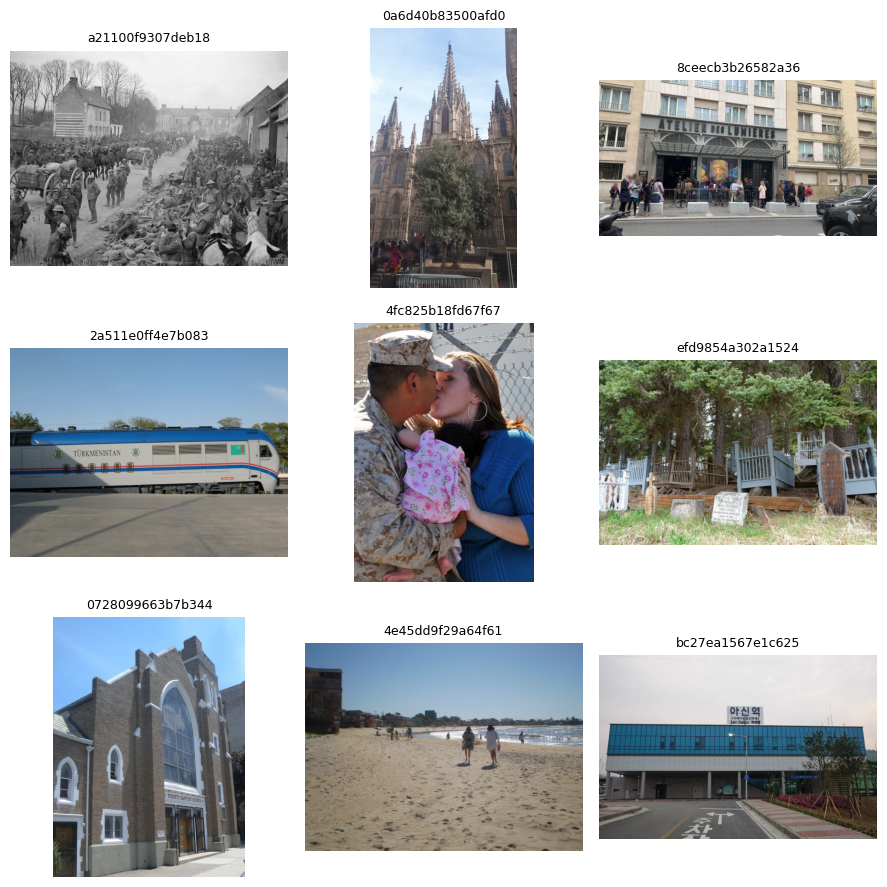

In [ ]:
sample_ids = test_df_clean.sample(min(9, len(test_df_clean)), random_state=42)['id'].tolist()
show_images_from_list(sample_ids, TEST_DIR, max_cols=3)

In [ ]:
test_ids = test_df_clean['id'].values
test_paths = [id_to_path(TEST_DIR, i) for i in test_ids]

def load_batch(paths, target_size=(224,224)):
    batch = []
    valid_idx = []
    for i, p in enumerate(paths):
        try:
            img = Image.open(p).convert('RGB').resize(target_size)
            batch.append(np.array(img, dtype=np.uint8))
            valid_idx.append(i)
        except Exception:
            pass
    if not batch:
        return None, valid_idx
    return np.stack(batch, axis=0), valid_idx

batch_size = 64
save_every = 5000
checkpoint_file = 'test_topn_checkpoint.csv'

if os.path.exists(checkpoint_file):
    prev_df = pd.read_csv(checkpoint_file)
    p0_list = prev_df['p0'].tolist()
    p1_list = prev_df['p1'].tolist()
    p2_list = prev_df['p2'].tolist()
    start_idx = len(p0_list)
else:
    p0_list, p1_list, p2_list = [], [], []
    start_idx = 0

for start in tqdm(range(start_idx, len(test_paths), batch_size), desc='Test Places365'):
    batch_paths = test_paths[start:start+batch_size]
    batch_data, valid_idx = load_batch(batch_paths)
    top3_batch = np.full((len(batch_paths), 3), -1, dtype=int)
    
    if batch_data is not None:
        preds = model.predict(batch_data, verbose=0)
        top3_valid = np.argsort(preds, axis=1)[:, -3:][:, ::-1]
        for j, v in enumerate(valid_idx):
            top3_batch[v] = top3_valid[j]
    
    p0_list.extend(top3_batch[:,0].tolist())
    p1_list.extend(top3_batch[:,1].tolist())
    p2_list.extend(top3_batch[:,2].tolist())

    if (start + batch_size) % save_every == 0 and len(p0_list) > 0:
        pd.DataFrame({
            'id': test_ids[:len(p0_list)],
            'p0': p0_list, 'p1': p1_list, 'p2': p2_list
        }).to_csv(checkpoint_file, index=False)

pd.DataFrame({
    'id': test_ids,
    'p0': p0_list, 'p1': p1_list, 'p2': p2_list
}).to_csv('test_topn_full.csv', index=False)
print("Готово! Сохранён test_topn_full.csv")

Test Places365: 100%|██████████| 124/124 [26:07<00:00, 12.64s/it]

Готово! Сохранён test_topn_full.csv


In [ ]:
test_topn = pd.read_csv('test_topn_full.csv')

for col in ['p0', 'p1', 'p2']:
    test_topn[col + '_landmark'] = test_topn[col].map(
        class_info.set_index('class')['io'].replace({1:'non-landmark', 2:'landmark'})
    )

test_landmark_ids = test_topn[test_topn['p0_landmark'] == 'landmark']['id']
test_df_final = test_df_clean[test_df_clean['id'].isin(test_landmark_ids)].reset_index(drop=True)

print(f"Осталось landmark-изображений: {len(test_df_final)} из {len(test_df_clean)}")

Осталось landmark-изображений: 5582 из 7926


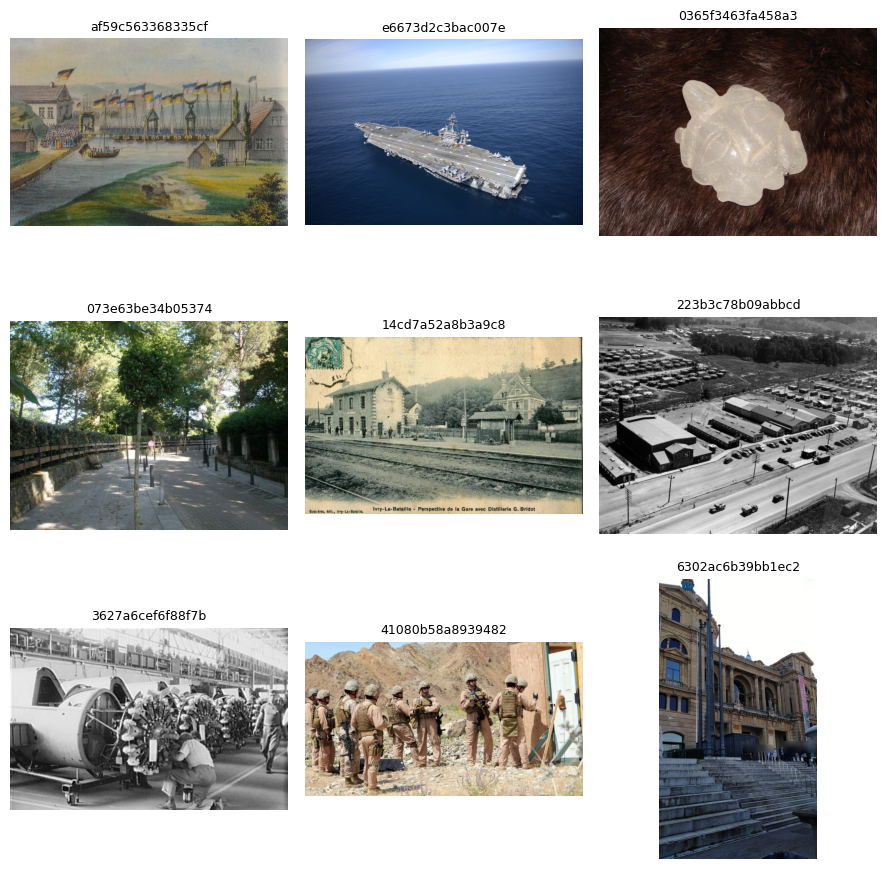

In [81]:
sample_ids = test_df_final.sample(min(9, len(test_df_final)), random_state=42)['id'].tolist()
show_images_from_list(sample_ids, TEST_DIR, max_cols=3)

In [ ]:
test_df_final.to_csv('test_landmark_clean.csv', index=False)

In [ ]:
def stratified_train_val_split(
    df,
    val_size=0.1,
    seed=42,
    min_count=5,
    add_distractors=True,
    distractor_ratio=0.2,
    save_dir=None
):

    counts = df["landmark_id"].value_counts()

    valid_classes = counts[counts >= min_count].index
    filtered = df[df["landmark_id"].isin(valid_classes)].copy()

    print(f"After filtering: {len(filtered)} images, {len(valid_classes)} classes")


    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)

    train_idx, val_idx = next(sss.split(filtered["id"], filtered["landmark_id"]))

    train_split = filtered.iloc[train_idx].reset_index(drop=True)
    val_split = filtered.iloc[val_idx].reset_index(drop=True)

    print(f"Train: {train_split.shape}, Val: {val_split.shape}")


    if add_distractors:
        rare = df[~df["landmark_id"].isin(valid_classes)].copy()

        n_distractors = int(len(val_split) * distractor_ratio)

        if len(rare) > 0:
            distractors = rare.sample(min(n_distractors, len(rare)), random_state=seed)
            distractors = distractors.copy()
            distractors["landmark_id"] = -1

            val_split = pd.concat([val_split, distractors], ignore_index=True)

            print(f"Added distractors: {len(distractors)}")


    val_gt = val_split[val_split["landmark_id"] != -1].copy()


    if save_dir is not None:
        save_dir = Path(save_dir)

        train_split.to_csv(save_dir / "train_split.csv", index=False)
        val_split.to_csv(save_dir / "val_split.csv", index=False)
        val_gt.to_csv(save_dir / "val_gt.csv", index=False)

        print("Saved splits to:", save_dir)

    return train_split, val_split, val_gt

In [87]:
train_df = train_df_final

train_split, val_split, val_gt = stratified_train_val_split(
    train_df,
    val_size=0.2,
)

print(f"Train: {len(train_split)} | Val: {len(val_split)}")
print(len(val_gt))

After filtering: 1322248 images, 60479 classes
Train: (1057798, 2), Val: (264450, 2)
Added distractors: 52890
Train: 1057798 | Val: 317340
264450


In [88]:
train_split.to_csv('train_split.csv', index=False)
val_split.to_csv('val_split.csv', index=False)
val_gt.to_csv('val_gt.csv', index=False)